# Split-cost agent trajectories

In [1]:
import sys
sys.path.append('/Users/benny/Repos/octagon_analysis')

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from parse_data import prepare_data
from parse_data import identify_filepaths
import globals
from plotting import plot_trajectory, plot_octagon

from data_extraction import get_indices
import seaborn as sns

from analysis import heatmap_phigh
import time
from data_extraction import extract_trial
import pandas as pd
from trajectory_analysis import trajectory_headangle, trajectory_vectors
from analysis import wall_visibility_and_choice
import matplotlib.pyplot as plt


In [3]:
data_folder = '/Users/benny/swc/agents/data/split_cost_results_260707'
solo_files = identify_filepaths.get_relative_paths('solo', data_folder)

In [4]:
df_solo, trial_lists_solo = prepare_data.prepare_data(data_folder, solo_files, combine=False)

IntProgress(value=0, max=45)

filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_0/2026-06-25_22-38-05_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_1/2026-06-26_04-04-58_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_2/2026-06-26_09-30-23_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_4/2026-06-26_20-22-51_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_5/2026-06-27_01-51-03_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_6/2026-06-27_07-15-15_solo.json
Loading complete.
Preprocessing complete.
filepath: /Users/benny/swc/agents/data/split_cost_results_260707/260707_7/2026-06-27_12-44-07_solo.json
Loading complete.
Pr

In [5]:
dfs = df_solo
trial_lists = trial_lists_solo
num_players = 1

In [6]:
dropped_trials = 1

In [7]:
dfs_cropped = []
for i in range(len(dfs)):
    df = dfs[i]
    mask = df['eventDescription'] == 'trial end'
    if mask.any():
        first_end_idx = df.index[mask][0]
        print(f"First trial end event found at index: {first_end_idx}")
        df = df.loc[first_end_idx + 1:]
    dfs_cropped.append(df)

First trial end event found at index: 655
First trial end event found at index: 555
First trial end event found at index: 621
First trial end event found at index: 638
First trial end event found at index: 605
First trial end event found at index: 655
First trial end event found at index: 688
First trial end event found at index: 655
First trial end event found at index: 655
First trial end event found at index: 588
First trial end event found at index: 671
First trial end event found at index: 605
First trial end event found at index: 2288
First trial end event found at index: 605
First trial end event found at index: 588
First trial end event found at index: 688
First trial end event found at index: 721
First trial end event found at index: 588
First trial end event found at index: 621
First trial end event found at index: 555
First trial end event found at index: 588
First trial end event found at index: 555
First trial end event found at index: 521
First trial end event found at in

In [8]:
trial_lists = [trial_list[dropped_trials:] for trial_list in trial_lists]

### Parameter value extraction

In [9]:
import agent_analysis.functions.preprocessing as prep

In [ ]:
folders, step_penalties, thetas = prep.extract_step_penalties(data_folder, yaml_filename=None)

No YAML file in add_later
No YAML file in excluded


In [30]:
log_ratios = []

for theta in (thetas):
    translation_cost, turning_cost = theta

    if translation_cost <= 0 or turning_cost <= 0:
        continue

    log_ratios.append(
        np.log2(translation_cost / turning_cost)
    )

## Session trajectories

In [11]:
import agent_analysis.functions.plotting as plot

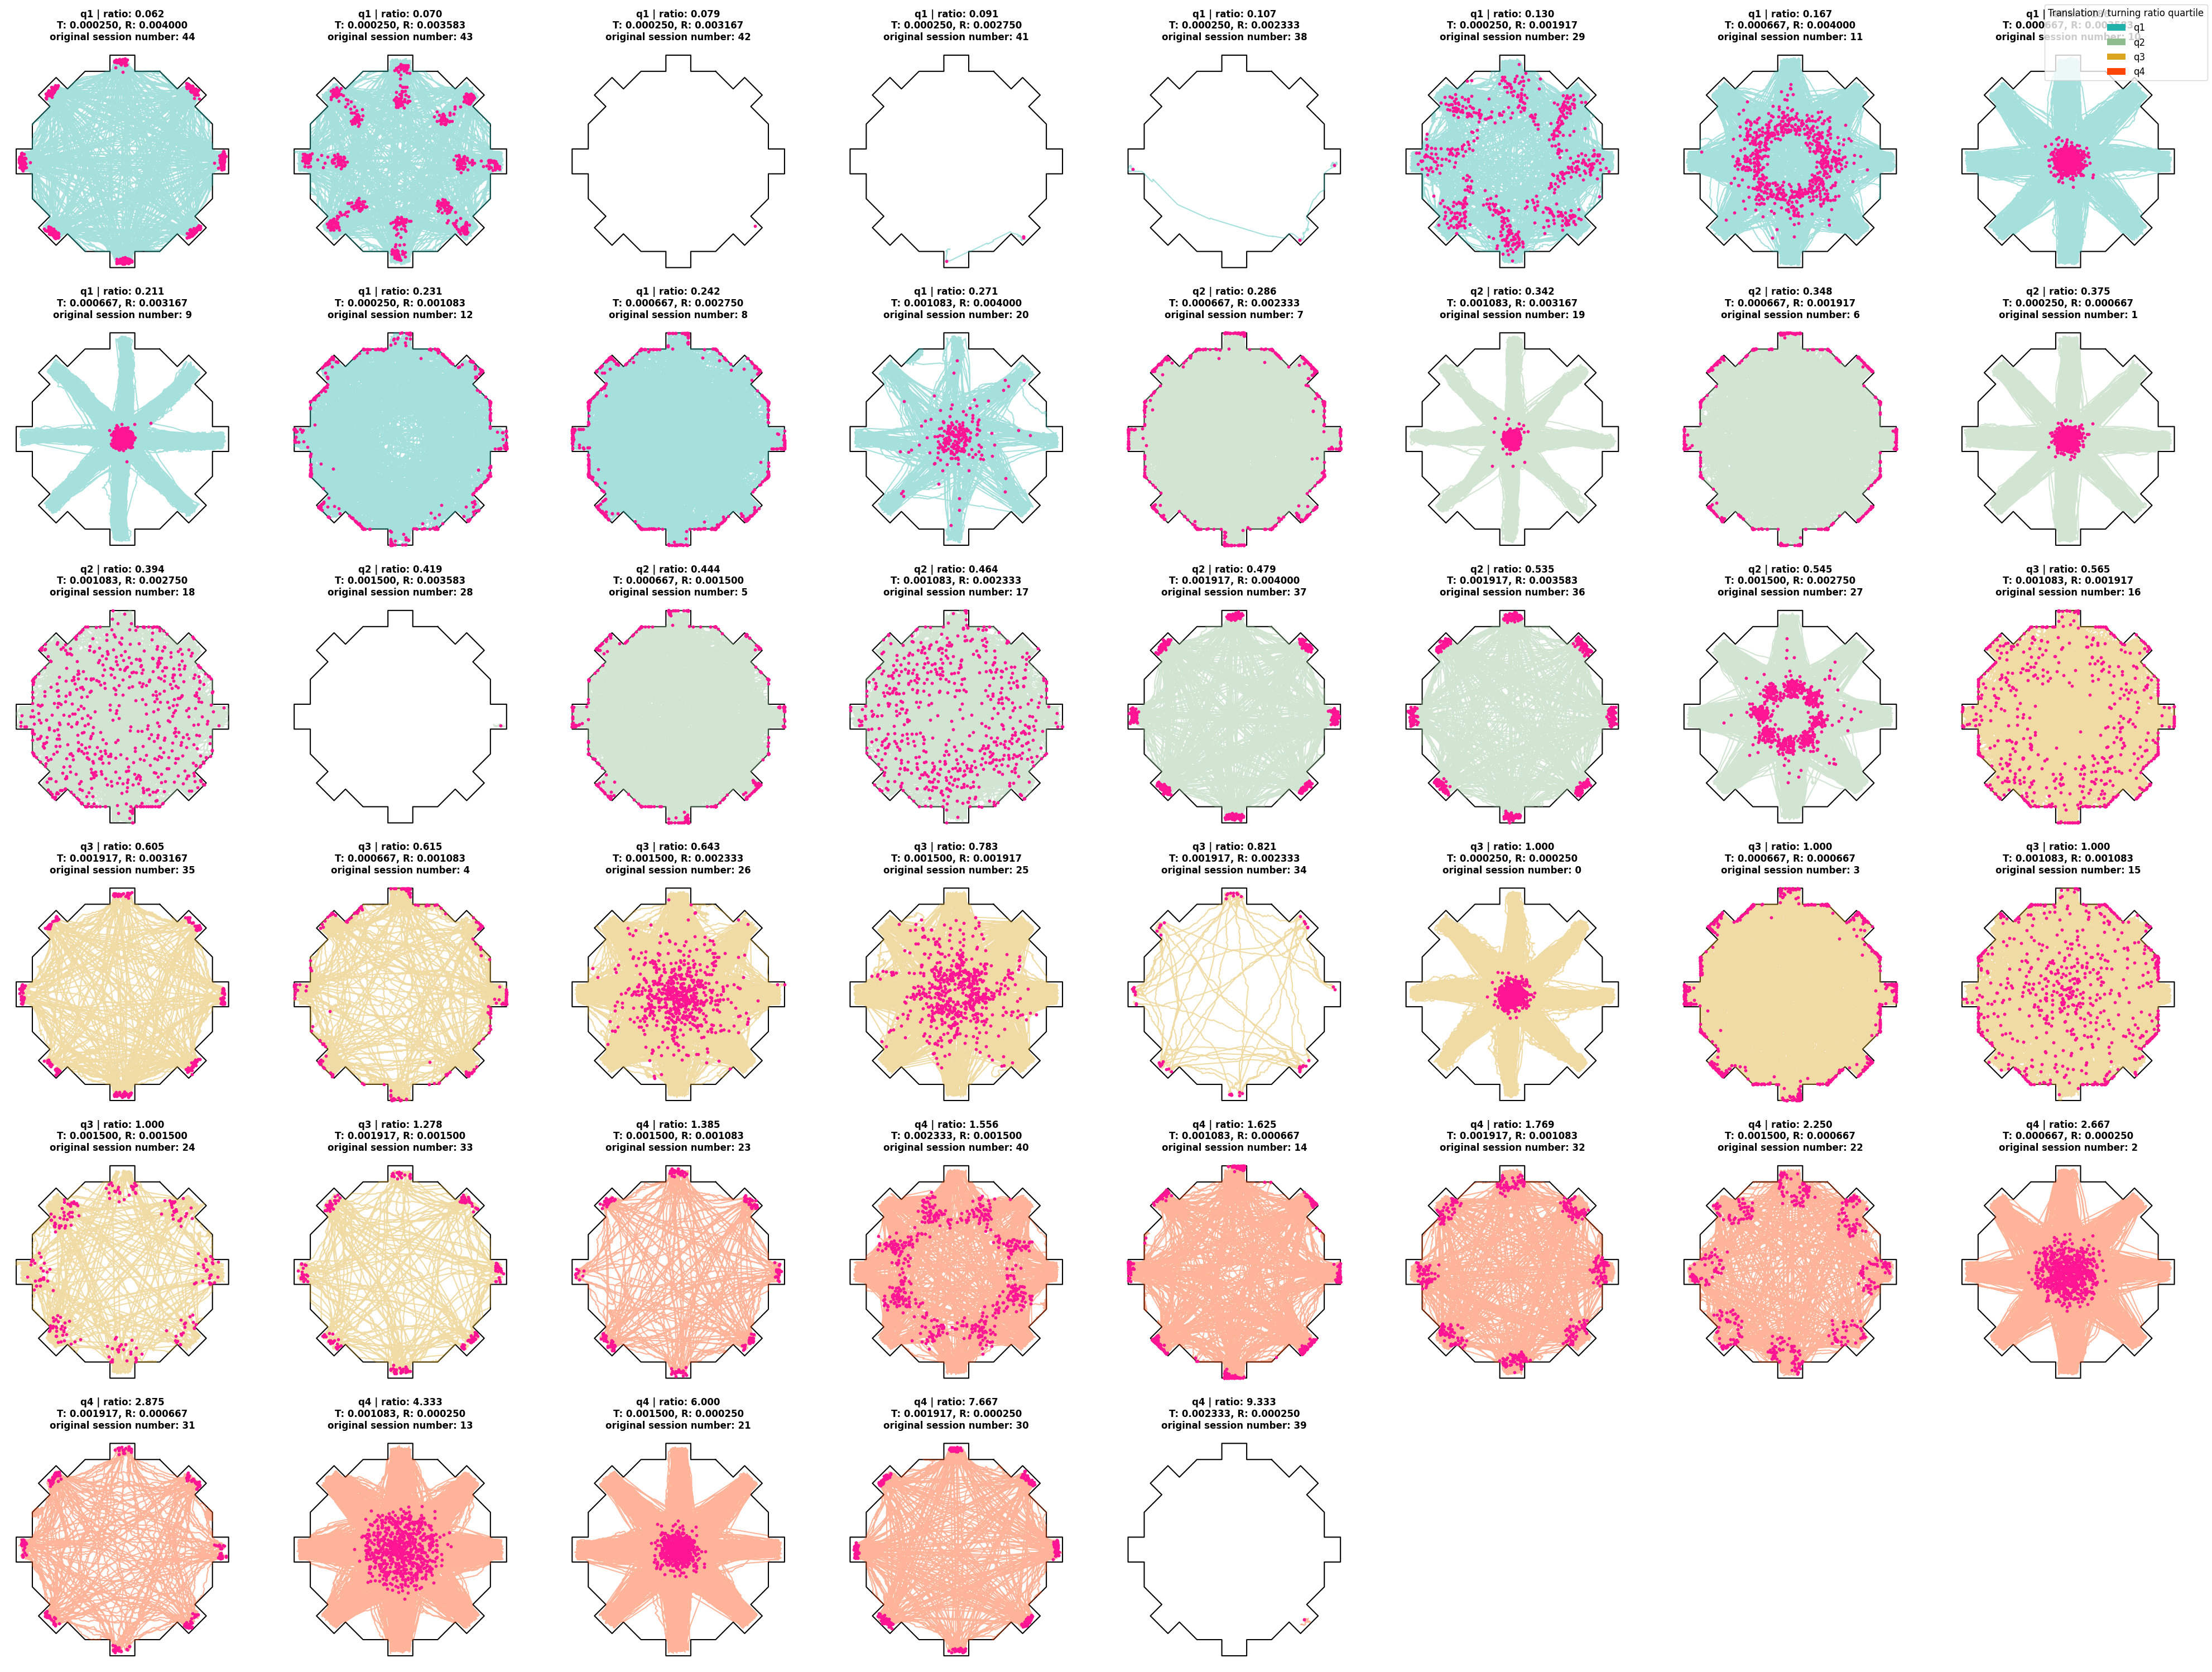

In [12]:
plot.plot_sorted_split_cost_session_trajectories(dfs_cropped, thetas, color_by_quartile=True)

# Centrality by ratio

In [13]:
from analysis import opponent_visibility

Get slice onset positions for each session for each trial

In [14]:
slice_onset_positions_dict = {}
for j, trial_list in enumerate(trial_lists):
    pos_list = []
    for i in range(len(trial_list)):
        if i == 0:
            continue
        slice_onset_positions = (opponent_visibility.get_player_position_slice_onset(player_id=0, trial=None, trial_list=trial_list, trial_index=i))
        pos_list.append(slice_onset_positions)
    slice_onset_positions_dict[j] = pos_list

Find the arena radius through the data

In [15]:
all_positions = np.array([
    pos for pos_list in slice_onset_positions_dict.values()
    for pos in pos_list
    if pos is not None
])

In [16]:
arena_radius = np.nanmax(np.linalg.norm(all_positions, axis=1))

In [17]:
arena_radius

np.float64(19.827257027307194)

In [18]:
centrality_dict = {}
mean_centrality_dict = {}
for j, pos_list in slice_onset_positions_dict.items():
    centrality_dict[j] = []
    for pos in pos_list:
        if pos is None:
            centrality_dict[j].append(np.nan)
            continue
        dist = np.linalg.norm(pos)
        centrality = 1 - (dist / arena_radius) if arena_radius > 0 else 1.0
        centrality_dict[j].append(centrality)
    mean_centrality_dict[j] = np.nanmean(centrality_dict[j])

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_66496/4289399188.py:12: RuntimeWarning: Mean of empty slice
  mean_centrality_dict[j] = np.nanmean(centrality_dict[j])


In [24]:
mean_centrality_dict[0]

np.float64(0.9221918717921365)

In [34]:
mean_centrality_list = []
std_centrality_list = []
sem_centrality_list = []
#sorted_ratios = []
sorted_log_ratios = []

for theta, session_id in sorted(
    #zip(thetas, mean_centrality_dict.keys()),
    zip(log_ratios, mean_centrality_dict.keys())
):
    #translation_cost = theta[0]
    #turning_cost = theta[1]
    #ratio = translation_cost / turning_cost
    ratio = theta

    values = np.array(centrality_dict[session_id], dtype=float)

    mean_centrality_list.append(np.nanmean(values))
    std_centrality_list.append(np.nanstd(values))
    sem_centrality_list.append(
        np.nanstd(values) / np.sqrt(np.sum(~np.isnan(values)))
    )
    #sorted_ratios.append(ratio)
    sorted_log_ratios.append(ratio)

/var/folders/1x/_8ffcp0j537dvfxsh4ygtrfw0000gn/T/ipykernel_66496/2194242323.py:18: RuntimeWarning: Mean of empty slice
  mean_centrality_list.append(np.nanmean(values))
/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [35]:
sorted_log_ratios

[np.float64(-4.0),
 np.float64(-3.841302253980942),
 np.float64(-3.662965012722429),
 np.float64(-3.4594316186372973),
 np.float64(-3.2223924213364477),
 np.float64(-2.9385994553358565),
 np.float64(-2.584962500721156),
 np.float64(-2.426264754702098),
 np.float64(-2.2479275134435857),
 np.float64(-2.115477217419936),
 np.float64(-2.0443941193584534),
 np.float64(-1.8845227825800641),
 np.float64(-1.807354922057604),
 np.float64(-1.5474877953024933),
 np.float64(-1.5235619560570128),
 np.float64(-1.415037499278844),
 np.float64(-1.3439544012173614),
 np.float64(-1.2563397532597858),
 np.float64(-1.1699250014423124),
 np.float64(-1.106915203916512),
 np.float64(-1.0614005446641435),
 np.float64(-0.9027027986450852),
 np.float64(-0.8744691179161412),
 np.float64(-0.8231222379159209),
 np.float64(-0.7243655573865726),
 np.float64(-0.7004397181410921),
 np.float64(-0.6374299206152919),
 np.float64(-0.3536369546147006),
 np.float64(-0.2837929660005911),
 np.float64(0.0),
 np.float64(0.0),
 

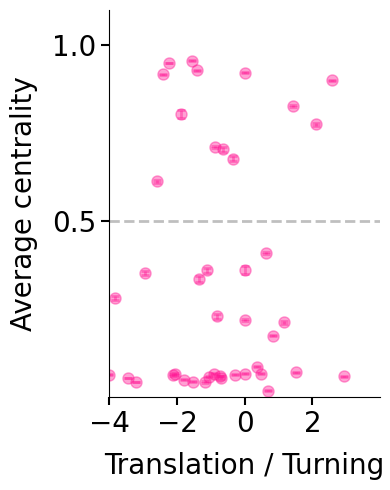

In [36]:
plt.figure(figsize=(4, 5))

plt.errorbar(
    sorted_log_ratios,
    mean_centrality_list,
    yerr=sem_centrality_list,
    fmt='o',
    alpha=0.4,
    color="deeppink",
    markersize=8,
    ecolor='deeppink',
    elinewidth=2,
    capsize=3,
    capthick=2,
    linestyle='none'
)

plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)

plt.xlabel("Translation / Turning", fontsize=20, labelpad=10)
plt.ylabel("Average centrality", fontsize=20, labelpad=10)

plt.xlim(-4, 4)  # shows the unsampled region past ~8
plt.xticks(np.arange(-4, 4, 2), fontsize=20)

plt.ylim([0.7, 1.1])
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)

plt.setp(ax.get_yticklabels()[0], visible=False)
plt.setp(ax.get_yticklines()[0], visible=False)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

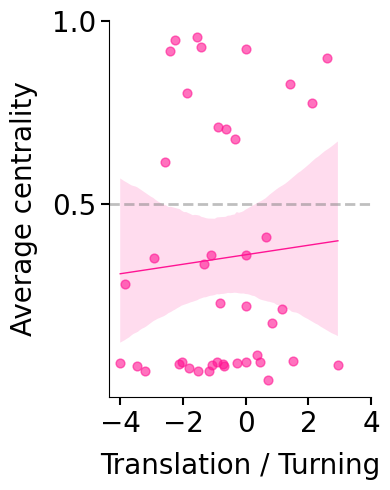

In [37]:
plt.figure(figsize=(4, 5))

sns.regplot(
    x=sorted_log_ratios,
    y=mean_centrality_list,
    scatter_kws={"color": "deeppink", "s": 40, "alpha": 0.6},
    line_kws={"color": "deeppink", "linewidth": 1},
    ci=95
)

plt.axhline(0.5, color='gray', alpha=0.5, linestyle='--', linewidth=2)

plt.xlabel("Translation / Turning", fontsize=20, labelpad=10)
plt.ylabel("Average centrality", fontsize=20, labelpad=10)

plt.xticks(np.arange(-4, 4 + 0.1, 2), fontsize=20)
plt.yticks(np.arange(0, 1.1, 0.5), fontsize=20)

ax = plt.gca()
ax.tick_params(width=1.5, length=6)

plt.setp(ax.get_yticklabels()[0], visible=False)
plt.setp(ax.get_yticklines()[0], visible=False)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

### range for full parameter space:


**min**: 0.00025 / 0.004 = 0.0625

**max**: 0.004 / 0.00025 = 16

**equal costs**: 1


### range for natural log:


**min**: log(0.0625) ≈ -2.773

**max**: log(16) ≈ 2.773

**equal costs**: 0